In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [3]:
df.shape
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print(df.head())

   age  job  marital  education  ...  cons.conf.idx  euribor3m  nr.employed  y
0   56    3        1          0  ...          -36.4      4.857       5191.0  0
1   57    7        1          3  ...          -36.4      4.857       5191.0  0
2   37    7        1          3  ...          -36.4      4.857       5191.0  0
3   40    0        1          1  ...          -36.4      4.857       5191.0  0
4   56    7        1          3  ...          -36.4      4.857       5191.0  0

[5 rows x 21 columns]


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()



X = df.drop('y', axis=1)
y= df['y']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = .2, random_state=42)

model = LogisticRegression(max_iter=5000, solver="saga", class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print('Accuracy: ', accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))

Accuracy:  0.8491138625880068
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7303
           1       0.42      0.88      0.57       935

    accuracy                           0.85      8238
   macro avg       0.70      0.86      0.74      8238
weighted avg       0.92      0.85      0.87      8238



In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random forest accuracy:", accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))  

Random forest accuracy: 0.8647730031561058
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      7303
           1       0.45      0.90      0.60       935

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.92      0.86      0.88      8238



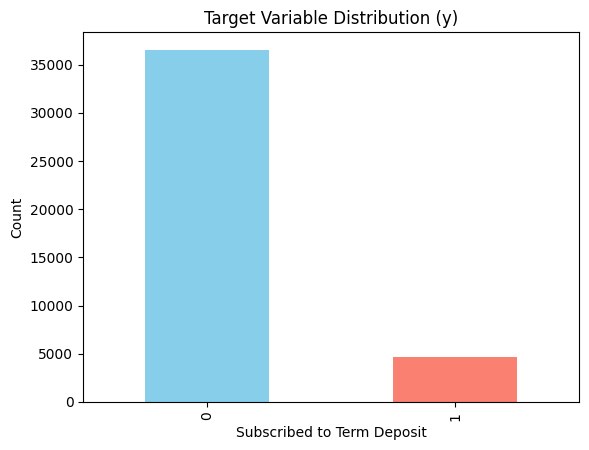

In [14]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Target Variable Distribution (y)")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Count")
plt.show()


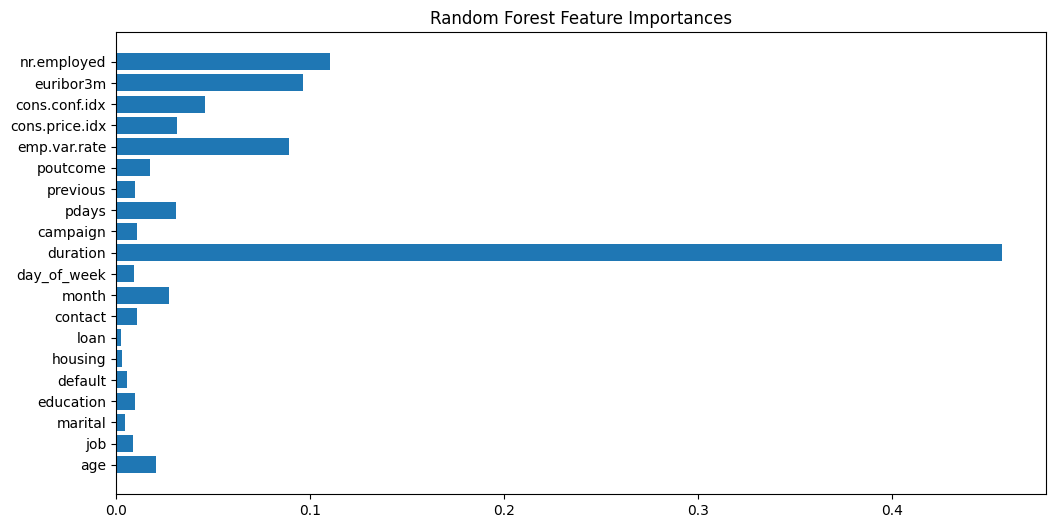

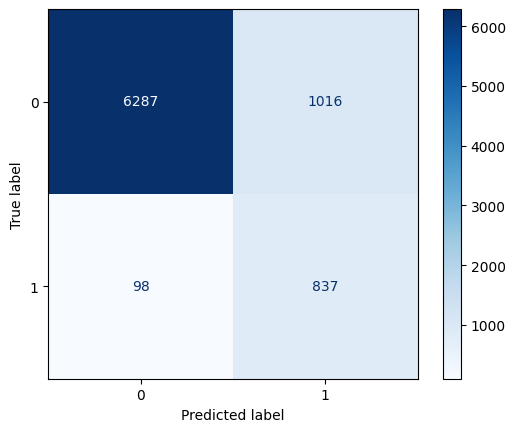

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Feature importances
importances = rf.feature_importances_
features = X.columns
plt.figure(figsize=(12,6))
plt.barh(features, importances)
plt.title("Random Forest Feature Importances")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()
